In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import torch
import src
import matplotlib.pyplot as plt
from src.utils.utils import set_seed
import src.data.catalog as catalog
import src.catalogs as catalogs
import matplotlib.pyplot as plt
import numpy as np 
set_seed(0) 
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [2]:
from src.models.builders import ModelBuilder
from src.train.config_setup import load_args_from_checkpoint,load_model_from_checkpoint
checkpoint_dir = Path("../checkpoints/reg_mixer_attnpl_t_20260130-225849") 
checkpoint_path = checkpoint_dir / "best_model_1.pth"
check_point = torch.load(checkpoint_path,weights_only=False)
args = load_args_from_checkpoint(None, check_point)
model_builder = ModelBuilder.by_name(args.model.lower())()
model = model_builder(args, device)
model,_,_ = load_model_from_checkpoint(model, check_point)
model = torch.compile(model)
model.eval() 

Initializing MixerAdapter with stats: {'tau_unfiltered': 0.15339908988298961, 'tau_q025': 0.08114294020924717, 'tau_q05': 0.5134664350189269, 'tau_mean': 1.3070542199341526, 'tau_max': 25.18216435192153, 'tau_min': 0.0, 'time_max': 18770.72654999979, 'time_mean': 10030.9430649837, 'mag_completeness': 3.0, 'mag_mean': 3.456916005014626, 'mag_max': 8.0, 'mag_min': 3.0, 'b_value': 0.856738547623331, 'b_std': 0.0071499224812533796, 'b_n': 14358}
using extractor: attn_time_biased_mh time_bias_type: log extractor_config: {'fuse_mode': 'concat', 'use_ln': True, 'use_var_scale': True}
load_specific_parts: None
Checkpoint loaded: <All keys matched successfully>
hyperparameters: {'model': 'reg_mixer_attnpl_t', 'use_ema': False, 'batch_size': 64, 'accumulation_steps': 1, 'warmup_ratio': 0.1, 'learning_rate': 0.001, 'weight_decay': 0.01, 'scheduler_factor': None, 'scheduler_patience': None, 'scheduler_threshold': None, 'scheduler_min_lr': 1e-06, 'scheduler_type': 'step_warmup', 'step_lr_step_size_

OptimizedModule(
  (_orig_mod): TaskModel(
    (base_model): MixerModelWrapper(
      (encoder): MixerModel(
        (input_linear): Linear(in_features=1, out_features=64, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (layers): ModuleList(
          (0): Block(
            (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
            (mixer): Mamba2Rotary(
              (in_proj): Linear(in_features=64, out_features=514, bias=False)
              (conv1d): Conv1d(384, 384, kernel_size=(4,), stride=(1,), padding=(3,), groups=384)
              (act): SiLU()
              (norm): RMSNorm()
              (out_proj): Linear(in_features=128, out_features=64, bias=False)
              (rotary_emb): RotaryEmbeddingTime()
            )
            (dropout): Dropout(p=0.1, inplace=False)
            (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
            (mlp): GatedMLP(
              (fc1): Linear(in_features=64, out_features=256, bias=False)

In [3]:
model.eval()
model.extractor.g

Parameter containing:
tensor([-0.0015,  0.0057,  0.0058,  0.0116], device='cuda:0',
       requires_grad=True)

In [4]:
torch.min(model.base_model.encoder.input_linear.bias)

tensor(-0.0355, device='cuda:0', grad_fn=<MinBackward1>)

In [5]:
from src.data.preparation import prepare_data
base_dir = f"../data/{args.dataset}"
df, train_loader, val_loader, test_loader, catalog_ds = prepare_data(base_dir=base_dir, args=args,)

CSV files found: ['Chuandian2021.csv']
Catalog statistics: {'tau_unfiltered': 0.15339908988298961, 'tau_q025': 0.08114294020924717, 'tau_q05': 0.5134664350189269, 'tau_mean': 1.3070542199341526, 'tau_max': 25.18216435192153, 'tau_min': 0.0, 'time_max': 18770.72654999979, 'time_mean': 10030.9430649837, 'mag_completeness': 3.0, 'mag_mean': 3.456916005014626, 'mag_max': 8.0, 'mag_min': 3.0, 'b_value': 0.856738547623331, 'b_std': 0.0071499224812533796, 'b_n': 14358}
stas {'tau_unfiltered': 0.15339908988298961, 'tau_q025': 0.08114294020924717, 'tau_q05': 0.5134664350189269, 'tau_mean': 1.3070542199341526, 'tau_max': 25.18216435192153, 'tau_min': 0.0, 'time_max': 18770.72654999979, 'time_mean': 10030.9430649837, 'mag_completeness': 3.0, 'mag_mean': 3.456916005014626, 'mag_max': 8.0, 'mag_min': 3.0, 'b_value': 0.856738547623331, 'b_std': 0.0071499224812533796, 'b_n': 14358}
[✔] Loading cached data from: ../data/ChuanDian/processed/regressor/regressor_Mc_3_Mf_3_Tfore_180_Twindow_360_context_le

In [6]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu") 

In [7]:
import src.data.event_loader as loader
args.batch_size =32
data_loader = loader.get_dataloader(catalog_ds, batch_size=args.batch_size, shuffle=False, task_type=args.task_type)

In [26]:
for x, y in test_loader:
    x, y = x.to(device), y.to(device)
    

In [27]:
x[0,:,2]

tensor([3.2000, 3.0000, 3.1000, 3.2000, 3.0000, 3.0000, 3.3000, 3.5000, 3.1000,
        3.4000, 3.5000, 3.0000, 3.1000, 3.1000, 3.0000, 3.5000, 3.1000, 4.0000,
        3.5000, 3.4000, 3.3000, 3.0000, 3.9000, 4.2000, 3.2000, 3.0000, 3.5000,
        3.4000, 3.7000, 3.0000, 4.1000, 3.5000, 3.0000, 3.6000, 3.4000, 3.7000,
        3.3000, 4.1000, 5.1000, 3.7000, 4.0000, 3.1000, 3.4000, 3.5000, 5.0000,
        3.0000, 3.4000, 3.0000, 3.0000, 3.3000, 3.1000, 4.3000, 3.4000, 3.2000,
        3.4000, 4.1000, 3.0000, 3.2000, 3.4000, 3.4000, 3.2000, 3.1000, 3.0000,
        3.1000, 3.5000, 3.1000, 3.1000, 4.1000, 3.5000, 3.0000, 3.0000, 3.3000,
        3.2000, 3.1000, 3.3000, 3.0000, 3.2000, 3.3000, 3.0000, 3.9000, 3.7000,
        3.2000, 3.1000, 3.0000, 3.3000, 3.1000, 3.7000, 3.2000, 3.1000, 3.3000,
        3.3000, 3.3000, 3.1000, 3.4000, 3.5000, 3.1000, 3.0000, 3.3000, 3.0000,
        3.1000, 3.1000, 3.0000, 4.6000, 3.4000, 3.6000, 3.2000, 3.0000, 3.1000,
        3.5000, 3.8000, 3.0000, 3.4000, 

In [9]:
model.base_model.encoder.layers[2]


Block(
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (mixer): Mamba2Rotary(
    (in_proj): Linear(in_features=64, out_features=514, bias=False)
    (conv1d): Conv1d(384, 384, kernel_size=(4,), stride=(1,), padding=(3,), groups=384)
    (act): SiLU()
    (norm): RMSNorm()
    (out_proj): Linear(in_features=128, out_features=64, bias=False)
    (rotary_emb): RotaryEmbeddingTime()
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (mlp): GatedMLP(
    (fc1): Linear(in_features=64, out_features=256, bias=False)
    (fc2): Linear(in_features=128, out_features=64, bias=False)
  )
)

In [28]:
model.base_model.input_adapter(x)['features'][0,:,0]

tensor([-0.2629, -0.4343, -0.3486, -0.2629, -0.4343, -0.4343, -0.1773, -0.0059,
        -0.3486, -0.0916, -0.0059, -0.4343, -0.3486, -0.3486, -0.4343, -0.0059,
        -0.3486,  0.4224, -0.0059, -0.0916, -0.1773, -0.4343,  0.3368,  0.5938,
        -0.2629, -0.4343, -0.0059, -0.0916,  0.1654, -0.4343,  0.5081, -0.0059,
        -0.4343,  0.0797, -0.0916,  0.1654, -0.1773,  0.5081,  1.3649,  0.1654,
         0.4224, -0.3486, -0.0916, -0.0059,  1.2792, -0.4343, -0.0916, -0.4343,
        -0.4343, -0.1773, -0.3486,  0.6795, -0.0916, -0.2629, -0.0916,  0.5081,
        -0.4343, -0.2629, -0.0916, -0.0916, -0.2629, -0.3486, -0.4343, -0.3486,
        -0.0059, -0.3486, -0.3486,  0.5081, -0.0059, -0.4343, -0.4343, -0.1773,
        -0.2629, -0.3486, -0.1773, -0.4343, -0.2629, -0.1773, -0.4343,  0.3368,
         0.1654, -0.2629, -0.3486, -0.4343, -0.1773, -0.3486,  0.1654, -0.2629,
        -0.3486, -0.1773, -0.1773, -0.1773, -0.3486, -0.0916, -0.0059, -0.3486,
        -0.4343, -0.1773, -0.4343, -0.34

In [11]:
# x[0, :, 1]*args.Twindow/1.3
# model.base_model.input_adapter(x)['times']

In [12]:
model.eval()
model.extractor.t_mlp.to(device)
x = torch.linspace(0, 1, 100).unsqueeze(1)  
x = x.to(device)  
gamma, beta = model.extractor.t_mlp(x).chunk(2, dim=-1)  

In [13]:
def predict_all(model, data_loader, device, return_X=False):
    y_pred_list = []
    y_list = []
    X_list = [] if return_X else None

    model.eval()
    with torch.no_grad():
        for x, y in data_loader:
            x, y = x.to(device), y.to(device)
            if return_X:
                X = model.get_pooled_representation(x)
                X_list.append(X.detach().cpu())
            y_pred = model(x)
            y_pred_list.append(y_pred.detach().cpu())
            y_list.append(y.detach().cpu())

    y_pred_all = torch.cat(y_pred_list, dim=0).cpu().numpy()
    # flatten if shape is (N,1)
    if y_pred_all.ndim == 2 and y_pred_all.shape[1] == 1:
        y_pred_all = y_pred_all.squeeze(1)
    y_all = torch.cat(y_list, dim=0).cpu().numpy()

    if return_X:
        X_all = torch.cat(X_list, dim=0).cpu().numpy()
        return y_pred_all,  y_all, X_all
    return y_pred_all, y_all, None

In [16]:
from src.utils.metrics import regression_metrics, log_metrics, plot_and_save_roc_curve
y_pred_all, y_all, X_all = predict_all(model,val_loader, device, return_X=True)
start=0
end =400
regression_metrics(y_all[start:end], y_pred_all[start:end])  

{'RMSE': 0.12416651709356329,
 'MAE': 0.09980037464545323,
 'MSE': 0.015417323967146145,
 'MAPE': 23.854709533238626,
 'R2': 0.07154286430076862,
 'PearsonR': 0.356417648314361,
 'PearsonR_diff': 0.0345954122896696,
 'DA': 0.049723756906077346,
 'SpearmanR': 0.29587530179819,
 'SpearmanR_diff': 0.03866199429765287,
 'DTW': 11.783619672060013,
 'DTW_normalized': 0.06474516303329678}

/root/miniconda3/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


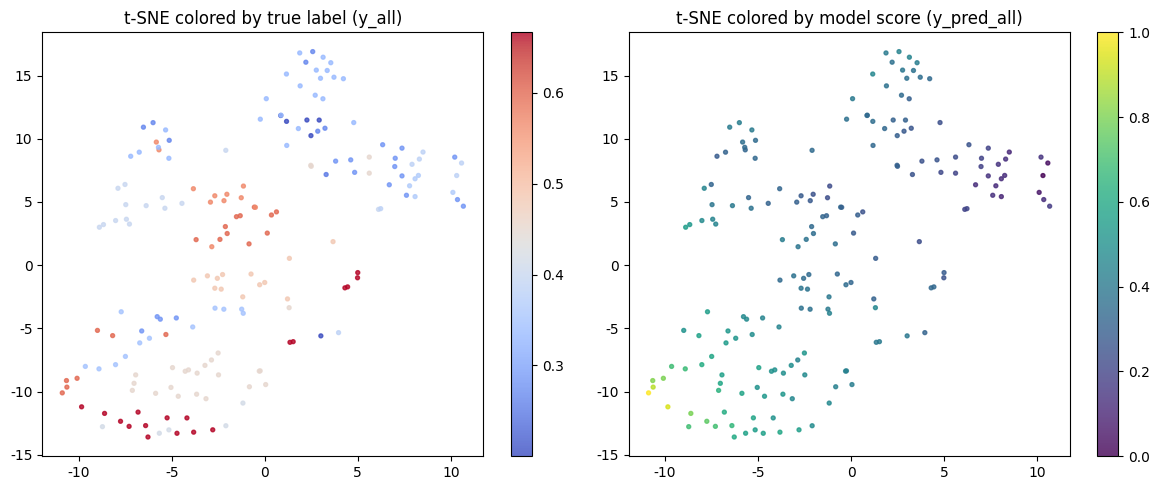

In [17]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# prepare features
X = X_all.astype(float)
X_scaled = StandardScaler().fit_transform(X)

# run t-SNE
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, n_iter=1000, random_state=0)
X_tsne = tsne.fit_transform(X_scaled)

# normalize predictions for coloring
y_score = (y_pred_all - y_pred_all.min()) / (y_pred_all.max() - y_pred_all.min())

# plot
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sc0 = axs[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_all, cmap="coolwarm", s=8, alpha=0.8)
axs[0].set_title("t-SNE colored by true label (y_all)")
plt.colorbar(sc0, ax=axs[0])

sc1 = axs[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_score, cmap="viridis", s=8, alpha=0.8)
axs[1].set_title("t-SNE colored by model score (y_pred_all)")
plt.colorbar(sc1, ax=axs[1])

plt.tight_layout()
plt.show()

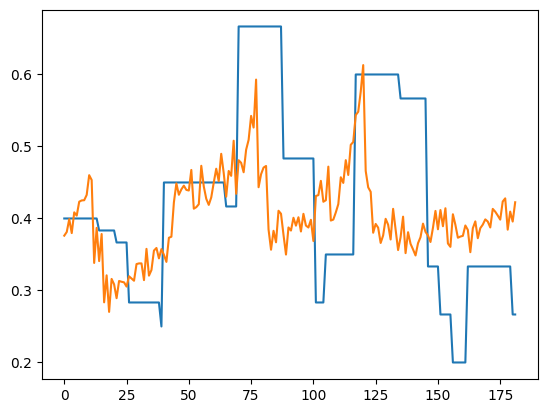

In [21]:
plt.plot(y_all,)
plt.plot(y_pred_all)

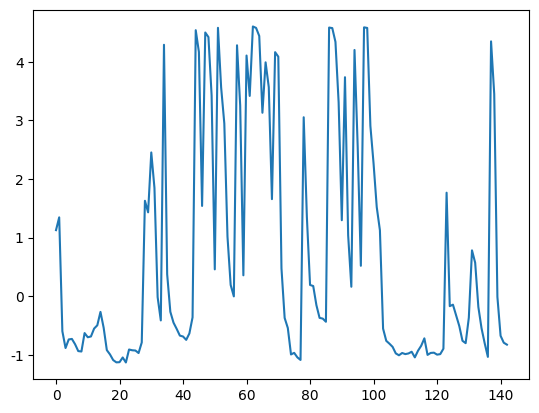

In [ ]:
plt.plot(y_pred_all)